In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [127]:
stadium_hourly = pd.read_csv('datasets/stadiums/stadium_hourly_averages.csv')
camp_monthly = pd.read_csv('datasets/camps/camps_daytime_averages.csv')

In [128]:
stadium_hourly[stadium_hourly['stadium']=='Estadio BBVA']

,month,day,hour,stadium,city,latitude,longitude,utc_offset_seconds,timezone,timezone_abbreviation,elevation,temperature_2m,relative_humidity_2m,apparent_temperature
4560,6,10,0,Estadio BBVA,Guadalupe,25.694199,-100.28293,-21600,America/Monterrey,GMT-6,494.0,25.886667,76.733333,29.626667
4561,6,10,1,Estadio BBVA,Guadalupe,25.694199,-100.28293,-21600,America/Monterrey,GMT-6,494.0,25.033333,81.266667,28.880000
4562,6,10,2,Estadio BBVA,Guadalupe,25.694199,-100.28293,-21600,America/Monterrey,GMT-6,494.0,24.540000,84.000000,28.660000
4563,6,10,3,Estadio BBVA,Guadalupe,25.694199,-100.28293,-21600,America/Monterrey,GMT-6,494.0,24.066667,86.066667,28.280000
4564,6,10,4,Estadio BBVA,Guadalupe,25.694199,-100.28293,-21600,America/Monterrey,GMT-6,494.0,23.500000,88.866667,27.726667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5011,6,28,19,Estadio BBVA,Guadalupe,25.694199,-100.28293,-21600,America/Monterrey,GMT-6,494.0,29.673333,52.666667,30.593333
5012,6,28,20,Estadio BBVA,Guadalupe,25.694199,-100.28293,-21600,America/Monterrey,GMT-6,494.0,28.133333,59.666667,29.513333
5013,6,28,21,Estadio BBVA,Guadalupe,25.694199,-100.28293,-21600,America/Monterrey,GMT-6,494.0,26.713333,66.133333,28.433333
5014,6,28,22,Estadio BBVA,Guadalupe,25.694199,-100.28293,-21600,America/Monterrey,GMT-6,494.0,25.660000,71.333333,27.646667


In [129]:
matches = pd.read_csv('matches.csv')
matches['kickoff'] = matches['date'] +' '+ matches['time']
matches['kickoff'] = pd.to_datetime(matches['kickoff'], format='%Y-%m-%d %H:%M')
matches['kickoff']

0    2026-06-11 13:00:00
1    2026-06-11 20:00:00
2    2026-06-18 12:00:00
3    2026-06-18 19:00:00
4    2026-06-24 19:00:00
             ...        
67   2026-06-17 19:00:00
68   2026-06-23 16:00:00
69   2026-06-23 19:00:00
70   2026-06-27 17:00:00
71   2026-06-27 17:00:00
Name: kickoff, Length: 72, dtype: datetime64[ns]

In [130]:
camp_info = camp_monthly[[ 'name','latitude', 'longitude','orig_team', 'elevation', 'temperature_2m', 'relative_humidity_2m', 'apparent_temperature']].copy()
# camp_in
# camp_info.rename(columns={'name':'camp_name', 'latitude':'camp_latitude', 'longitude':'camp_longitude'}, inplace=True)
camp_info = camp_info.add_prefix('camp_')
#camp_info_team2 = camp_info.add_prefix('team2_')

In [131]:
stadium_hourly['kickoff'] =  '2026' + (stadium_hourly['month'].astype(str).str.zfill(2) + 
    stadium_hourly['day'].astype(str).str.zfill(2) + ' ' + stadium_hourly['hour'].astype(str) )
stadium_hourly['kickoff'] = pd.to_datetime(stadium_hourly['kickoff'], format='%Y%m%d %H')
important_info = stadium_hourly[['kickoff','stadium', 'temperature_2m', 'relative_humidity_2m', 'elevation','apparent_temperature']].copy()
matches = matches.merge(important_info, on=['stadium', 'kickoff'])
# matches = matches.merge(camp_info_team1, how='left', left_on='team1',right_on='team1_orig_team')
# matches = matches.merge(camp_info_team2, how='left', left_on='team2',right_on='team2_orig_team')
matches

,match,group,date,time,tz,team1,team2,stadium,city_name,country,lat,lon,kickoff,temperature_2m,relative_humidity_2m,elevation,apparent_temperature
0,1,A,2026-06-11,13:00,UTC-6,Mexico,South Africa,Estadio Azteca,Mexico City,Mexico,19.303,-99.151,2026-06-11 13:00:00,25.100000,33.800000,2251.0,25.286667
1,2,A,2026-06-11,20:00,UTC-6,Korea Republic,Czechia,Estadio Akron,Zapopan,Mexico,20.689,-103.467,2026-06-11 20:00:00,24.206667,47.800000,1665.0,22.553333
2,25,A,2026-06-18,12:00,UTC-4,Czechia,South Africa,Mercedes-Benz Stadium,Atlanta,USA,33.755,-84.401,2026-06-18 12:00:00,29.153333,50.933333,316.0,31.093333
3,28,A,2026-06-18,19:00,UTC-6,Mexico,Korea Republic,Estadio Akron,Zapopan,Mexico,20.689,-103.467,2026-06-18 19:00:00,24.553333,48.066667,1665.0,23.466667
4,53,A,2026-06-24,19:00,UTC-6,Czechia,Mexico,Estadio Azteca,Mexico City,Mexico,19.303,-99.151,2026-06-24 19:00:00,18.800000,64.800000,2251.0,18.200000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,21,L,2026-06-17,19:00,UTC-4,Ghana,Panama,BMO Field,Toronto,Canada,43.633,-79.419,2026-06-17 19:00:00,22.386667,54.733333,83.0,20.706667
65,45,L,2026-06-23,16:00,UTC-4,England,Ghana,Gillette Stadium,Foxborough,USA,42.091,-71.264,2026-06-23 16:00:00,26.973333,53.800000,84.0,28.186667
66,46,L,2026-06-23,19:00,UTC-4,Panama,Croatia,BMO Field,Toronto,Canada,43.633,-79.419,2026-06-23 19:00:00,24.426667,59.066667,83.0,23.626667
67,67,L,2026-06-27,17:00,UTC-4,Panama,England,MetLife Stadium,East Rutherford,USA,40.814,-74.075,2026-06-27 17:00:00,25.906667,62.066667,4.0,26.833333


In [132]:
#matches.to_csv('match_climate_data.csv', index=False)

{'Czech Republic',
 'Czechia',
 'Korea Republic',
 'South Korea',
 'Turkey',
 'Türkiye',
 'USA',
 'United States'}

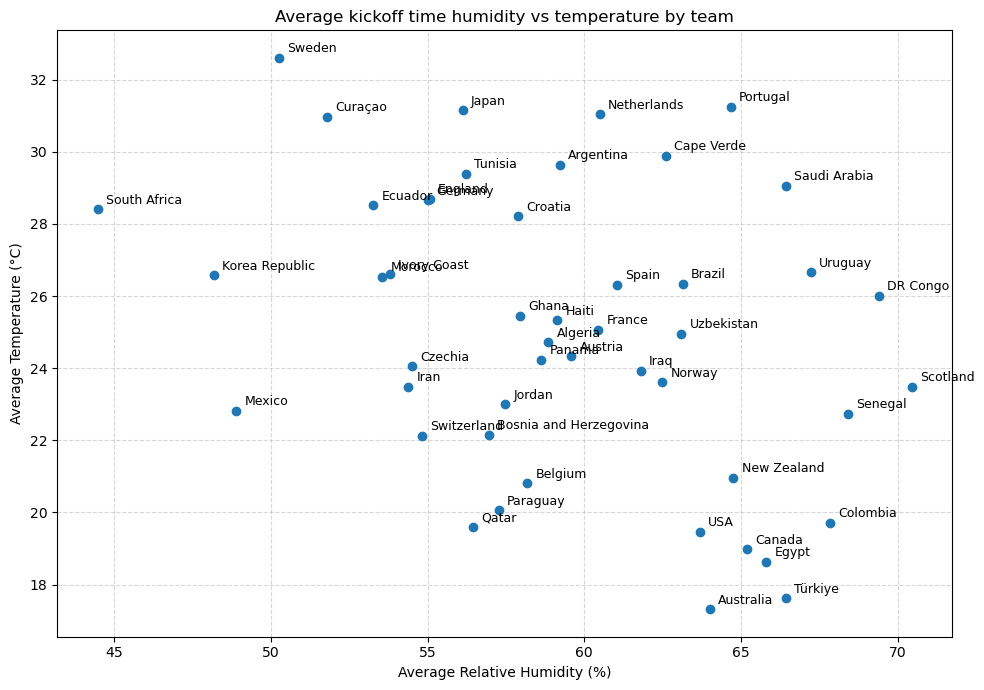

In [ ]:


# Combine team1 and team2 rows into one long dataframe
team1 = matches[['team1','elevation', 'temperature_2m', 'relative_humidity_2m','apparent_temperature']].rename(columns={'team1': 'team'})
team2 = matches[['team2', 'elevation','temperature_2m', 'relative_humidity_2m','apparent_temperature']].rename(columns={'team2': 'team'})

teams = pd.concat([team1, team2])

# Average per team
avg = teams.groupby('team')[['relative_humidity_2m', 'temperature_2m', 'elevation']].mean()

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(avg['relative_humidity_2m'], avg['temperature_2m'], zorder=3)

for team, row in avg.iterrows():
    ax.annotate(team, (row['relative_humidity_2m'], row['temperature_2m']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.set_xlabel('Average Relative Humidity (%)')
ax.set_ylabel('Average Temperature (°C)')
ax.set_title('Average kickoff time humidity vs temperature by team')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig("average_real_temp_vs_humidity.png")

In [134]:
teams_w_camp_info = teams.merge(camp_info, how='left', left_on='team', right_on='camp_orig_team')
teams_w_camp_info['temp_diff'] = teams_w_camp_info['apparent_temperature']  - teams_w_camp_info['camp_apparent_temperature'] 
teams_w_camp_info['elevation_diff'] = teams_w_camp_info['elevation']  - teams_w_camp_info['camp_elevation'] 

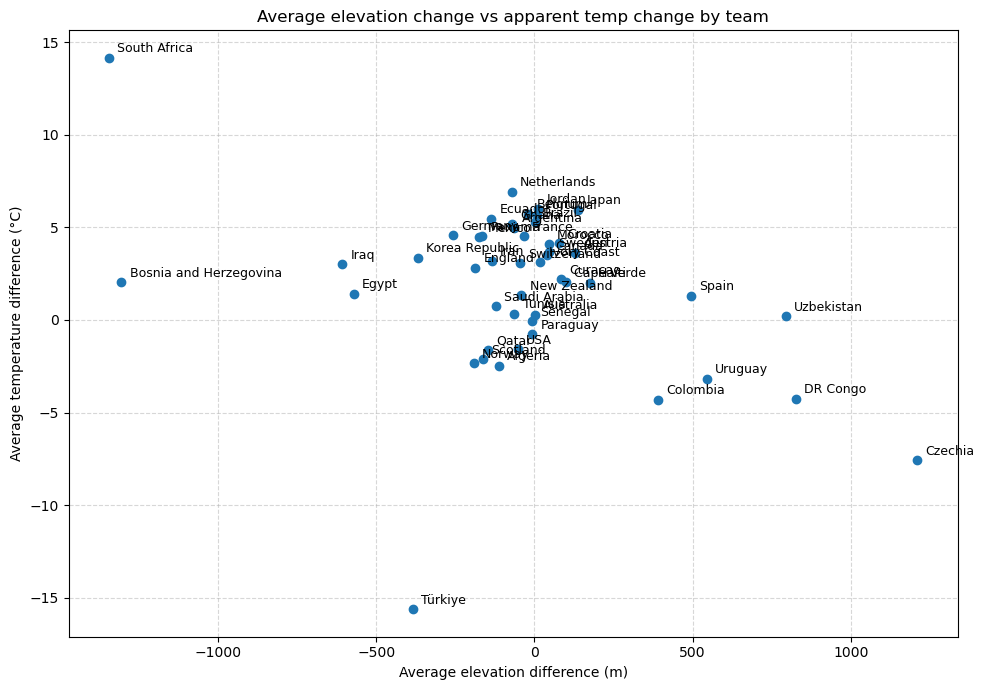

In [135]:
avg = teams_w_camp_info.groupby('team')[['temp_diff', 'elevation_diff']].mean()

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(avg['elevation_diff'], avg['temp_diff'], zorder=3)

for team, row in avg.iterrows():
    ax.annotate(team, (row['elevation_diff'], row['temp_diff']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.set_xlabel('Average elevation difference (m)')
ax.set_ylabel('Average temperature difference (°C)')
ax.set_title('Average elevation change vs apparent temp change by team')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

plt.savefig("temp_vs_elevation_differences.png")

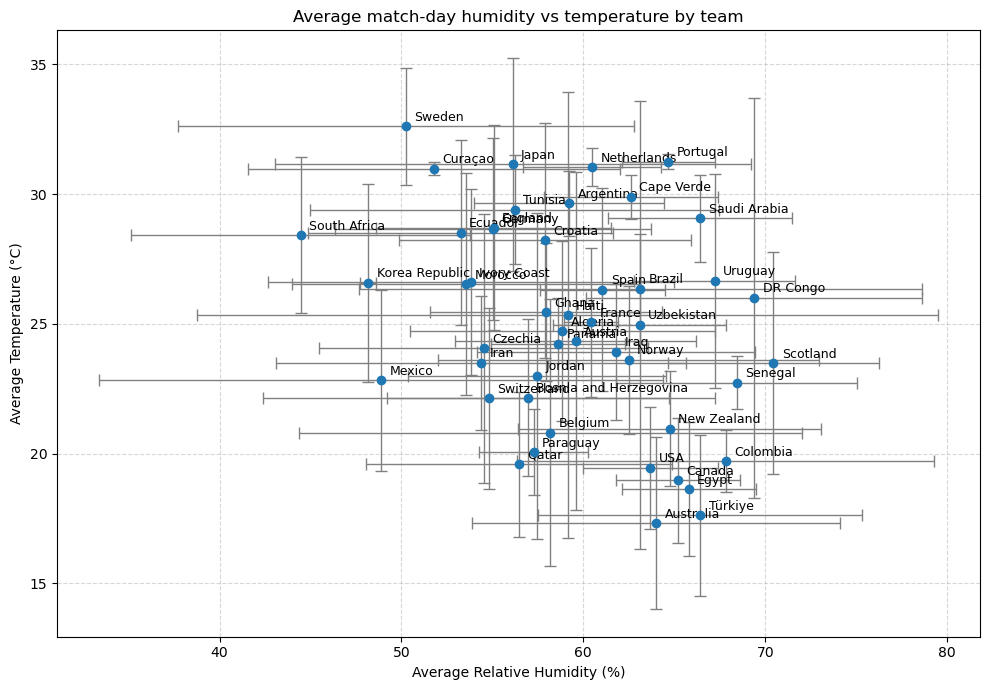

In [136]:
import pandas as pd
import matplotlib.pyplot as plt

# Combine team1 and team2 rows
team1 = matches[['team1', 'temperature_2m', 'relative_humidity_2m']].rename(columns={'team1': 'team'})
team2 = matches[['team2', 'temperature_2m', 'relative_humidity_2m']].rename(columns={'team2': 'team'})

teams = pd.concat([team1, team2])

# Average and std per team
avg = teams.groupby('team')[['relative_humidity_2m', 'temperature_2m']].mean()
std = teams.groupby('team')[['relative_humidity_2m', 'temperature_2m']].std()

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.errorbar(
    avg['relative_humidity_2m'],
    avg['temperature_2m'],
    xerr=std['relative_humidity_2m'],
    yerr=std['temperature_2m'],
    fmt='o',          # circle markers
    capsize=4,        # small caps at error bar ends
    elinewidth=1,
    ecolor='gray',
    zorder=3
)

for team, row in avg.iterrows():
    ax.annotate(team, (row['relative_humidity_2m'], row['temperature_2m']),
                textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.set_xlabel('Average Relative Humidity (%)')
ax.set_ylabel('Average Temperature (°C)')
ax.set_title('Average match-day humidity vs temperature by team')
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [137]:
match

NameError: name 'match' is not defined

{'Estadio Akron',
 'Estadio BBVA',
 'Estadio Guadalajara',
 'Estadio Monterrey',
 "Levi's Stadium",
 'San Francisco Bay Area Stadium'}